<a href="https://colab.research.google.com/github/aashish177/Atrium/blob/main/cugraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Mon Mar 16 16:39:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install cugraph-cu12 --extra-index-url=https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 150.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 206.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cuda-nvcc-cu12
    Found existing installation: nvidia-cuda-nvcc-cu12 12.5.82
    Uninstalling nvidia-cuda-nvcc-cu12-12.5.82:
      Successfully uninstalled nvidia-cuda-nvcc-cu12-12.5.82


In [3]:
import cugraph
import cudf

print("cuGraph installed successfully")

cuGraph installed successfully


In [5]:
import cugraph
import cudf

edges = cudf.DataFrame({
    "src": [0,1,2],
    "dst": [1,2,3]
})

G = cugraph.Graph()
G.from_cudf_edgelist(edges, source="src", destination="dst")

pr = cugraph.pagerank(G)
print(pr)

   vertex  pagerank
0       1  0.324561
1       2  0.324561
2       0  0.175439
3       3  0.175439


/usr/local/lib/python3.12/dist-packages/cugraph/link_analysis/pagerank.py:206: UserWarning: Pagerank expects the 'store_transposed' flag to be set to 'True' for optimal performance during the graph creation
  warnings.warn(warning_msg, UserWarning)


In [12]:
import cudf
import cupy as cp
import cugraph

N = 10000
E = 50000

edges = cudf.DataFrame({
    "src": cp.random.randint(0, N, E),
    "dst": cp.random.randint(0, N, E),
    "weight": cp.random.rand(E)
})

G = cugraph.Graph()
G.from_cudf_edgelist(edges, source="src", destination="dst", edge_attr="weight")

pr = cugraph.pagerank(G)
print(pr.head())

   vertex  pagerank
0     566  0.000201
1    1439  0.000190
2    3154  0.000183
3    4463  0.000202
4    9301  0.000223


/usr/local/lib/python3.12/dist-packages/cugraph/link_analysis/pagerank.py:206: UserWarning: Pagerank expects the 'store_transposed' flag to be set to 'True' for optimal performance during the graph creation
  warnings.warn(warning_msg, UserWarning)


In [13]:
parts, modularity = cugraph.louvain(G)

print(parts.head())
print("Modularity:", modularity)

   vertex  partition
0     566         55
1    1439         46
2    3154          1
3    4463         61
4    9301          4
Modularity: 0.3671734683490264


In [14]:
distances = cugraph.sssp(G, source=0)
print(distances.head())

   distance  vertex  predecessor
0  0.965064     566         3750
1  1.076428    1439         1174
2  0.989422    3154         4042
3  1.094795    4463         4164
4  1.045569    9301         2351


In [15]:
tri = cugraph.triangle_count(G)
print(tri.head())

   vertex  counts
0     566       0
1    1439       2
2    3154       0
3    4463       0
4    9301       0


In [16]:
G = cugraph.Graph(directed=False) # Triangles usually care about mutual connections
G.from_cudf_edgelist(edges, source="src", destination="dst")
tri = cugraph.triangle_count(G)
print(tri.head())

   vertex  counts
0     566       0
1    1439       2
2    3154       0
3    4463       0
4    9301       0


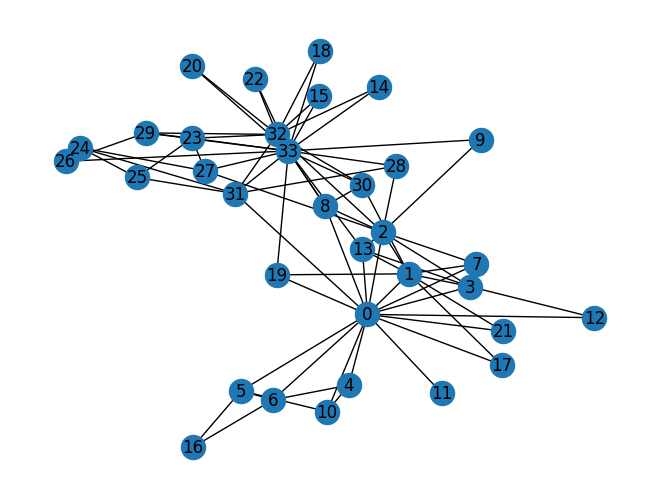

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

small = nx.karate_club_graph()
nx.draw(small, with_labels=True)
plt.show()

In [18]:
import networkx as nx
import time

nxG = nx.from_pandas_edgelist(edges.to_pandas(), "src", "dst")

start = time.time()
nx.pagerank(nxG)
print("CPU time: ", time.time() - start)

CPU time:  0.3323202133178711


In [19]:
!wget https://snap.stanford.edu/data/facebook_combined.txt

--2026-03-16 18:02:19--  https://snap.stanford.edu/data/facebook_combined.txt
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-16 18:02:20 ERROR 404: Not Found.



In [20]:
!wget https://snap.stanford.edu/data/facebook_combined.txt.gz

--2026-03-16 18:02:47--  https://snap.stanford.edu/data/facebook_combined.txt.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 218576 (213K) [application/x-gzip]
Saving to: ‘facebook_combined.txt.gz’

facebook_combined.t 100%[===================>] 213.45K   173KB/s    in 1.2s    

2026-03-16 18:02:49 (173 KB/s) - ‘facebook_combined.txt.gz’ saved [218576/218576]



In [21]:
!gunzip facebook_combined.txt.gz

In [24]:
import cudf
import cugraph

df = cudf.read_csv("facebook_combined.txt", sep=' ', names=['src', 'dst'], dtype=['int32', 'int32'])
print(f"Success! Loaded {len(df)} Facebook edges into the GPU.")


Success! Loaded 88234 Facebook edges into the GPU.


In [25]:
G = cugraph.Graph()
G.from_cudf_edgelist(df, source='src', destination='dst')

In [26]:
tri = cugraph.triangle_count(G)

In [27]:
print(tri.sort_values('counts', ascending=False).head())

    vertex  counts
2     1912   30025
0      107   26750
6     2347   16863
11    2266   16174
22    2206   15844


In [37]:
%env NX_CUGRAPH_AUTOCONFIG=True
import networkx as nx

G = nx.barabasi_albert_graph(1000, 3)
pr = nx.pagerank(G)
print({k: pr[k] for k in list(pr)[:5]})

env: NX_CUGRAPH_AUTOCONFIG=True
{0: 0.01369734139986159, 1: 0.008773156360645691, 2: 0.002788189056245377, 3: 0.003582024982942118, 4: 0.00415908792149869}


In [40]:
df = cudf.read_csv("facebook_combined.txt", sep=' ', names=['src', 'dst'], dtype=['int32', 'int32'])

G = cugraph.Graph()
G.from_cudf_edgelist(df, source='src', destination='dst')

degree_df = G.degree()
degree_df.columns = ['vertex', 'degree']

pagerank_df = cugraph.pagerank(G)

betweenness_df = cugraph.betweenness_centrality(G, k=100)

merged = degree_df.merge(pagerank_df, on='vertex').merge(betweenness_df, on='vertex')

print("Top Gatekeepers (High Betweenness):")
print(merged.sort_values('betweenness_centrality', ascending=False).head(5))

/usr/local/lib/python3.12/dist-packages/cugraph/link_analysis/pagerank.py:206: UserWarning: Pagerank expects the 'store_transposed' flag to be set to 'True' for optimal performance during the graph creation
  warnings.warn(warning_msg, UserWarning)


Top Gatekeepers (High Betweenness):
      vertex  degree  pagerank  betweenness_centrality
1088      58    1116  0.000211                0.088079
1089      58    1137  0.000211                0.088079
1090      58    1232  0.000211                0.088079
1091      58    1428  0.000211                0.088079
1092      58    1497  0.000211                0.088079


In [43]:
bfs_df = cugraph.bfs(G, start=0)
print("Distances from Vertex 0:")
print(bfs_df.sort_values('distance', ascending=False).head(5))

Distances from Vertex 0:
      vertex  distance  predecessor
806      705         6          800
990      824         6          774
1067     694         6          800
1106     781         6          800
1230     724         6          830


In [42]:
# Louvain gives us the communities and a modularity score
parts, modularity_score = cugraph.louvain(G)

print(f"Modularity Score: {modularity_score}")
print(parts.head(5)) # 'partition' column shows which group they belong to

Modularity Score: 0.8348224759101868
   vertex  partition
0     107          2
1    1684          4
2    1912          1
3    3437          5
4       0          6
